In [1]:
# Import required modules
import cv2
import numpy as np
import os
import glob
import json
from matplotlib import pyplot as plt

In [2]:
# Define the dimensions of checkerboard
CHECKERBOARD = (7, 7)
# stop the iteration when specified
# accuracy, epsilon, is reached or
# specified number of iterations are completed.
criteria = (cv2.TERM_CRITERIA_EPS + 
            cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [3]:
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = [] 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None

In [4]:
# Extracting path of individual image stored in a given directory
images = glob.glob('./*.JPG')
images

['.\\1.JPG', '.\\2.JPG', '.\\3.JPG', '.\\4.JPG', '.\\5.JPG', '.\\6.JPG']

In [5]:
for fname in images:
    img = cv2.imread(fname)
    if img is not None:
        print(f"Image: {fname}")
        print(f"Shape: {img.shape}")
        print(f"Data type: {img.dtype}")
        print(f"Min pixel value: {img.min()}")
        print(f"Max pixel value: {img.max()}")
        print("-" * 40)
    else:
        print(f"Image: {fname} could not be loaded.")

Image: .\1.JPG
Shape: (1080, 1920, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
----------------------------------------
Image: .\2.JPG
Shape: (1080, 1920, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
----------------------------------------
Image: .\3.JPG
Shape: (1080, 1920, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
----------------------------------------
Image: .\4.JPG
Shape: (1080, 1920, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
----------------------------------------
Image: .\5.JPG
Shape: (1080, 1920, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
----------------------------------------
Image: .\6.JPG
Shape: (1080, 1920, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
----------------------------------------


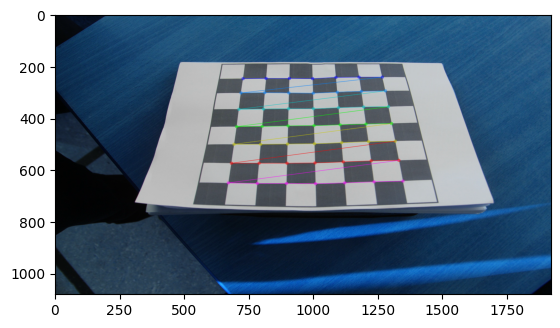

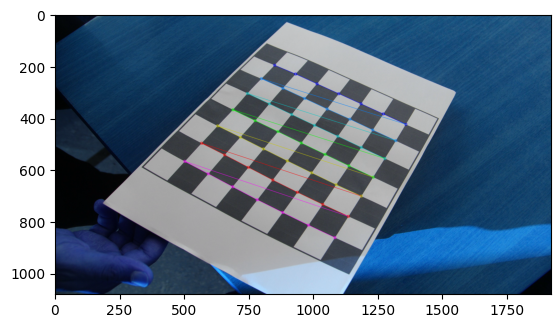

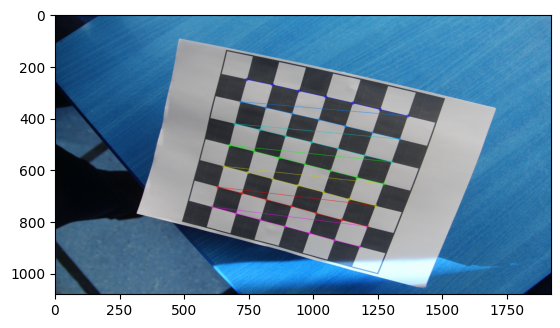

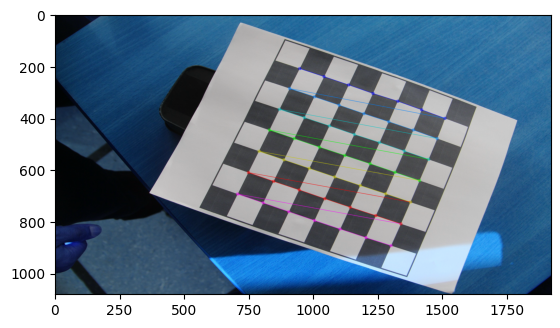

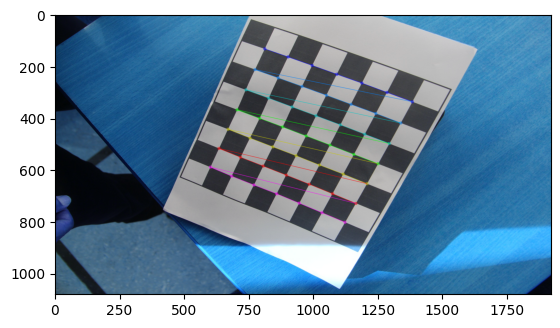

In [6]:
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display 
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
        cv2.imwrite(filename=f"{fname}_output.jpg",img=img)
        plt.imshow(img)
        plt.show()


In [12]:
h,w = img.shape[:2]
 
"""
Performing camera calibration by 
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the 
detected corners (imgpoints)
"""

# DSLR prior: principal point at image center
cx = w / 2
cy = h / 2

# Rough focal length guess (in pixels)
f_guess = 0.8 * w   # good generic guess for DSLR

init_camera_matrix = np.array([
    [f_guess, 0, cx],
    [0, f_guess, cy],
    [0, 0, 1]
], dtype=np.float64)

print("Initial camera matrix:")
print(init_camera_matrix)

Initial camera matrix:
[[1.536e+03 0.000e+00 9.600e+02]
 [0.000e+00 1.536e+03 5.400e+02]
 [0.000e+00 0.000e+00 1.000e+00]]


In [13]:
flags = (
    cv2.CALIB_USE_INTRINSIC_GUESS |   # use DSLR prior
    cv2.CALIB_FIX_PRINCIPAL_POINT |   # fix cx, cy
    cv2.CALIB_FIX_ASPECT_RATIO |      # fx = fy
    cv2.CALIB_ZERO_TANGENT_DIST |     # p1 = p2 = 0
    cv2.CALIB_FIX_K2 |                # disable k2
    cv2.CALIB_FIX_K3                  # disable k3
)

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], init_camera_matrix, None, flags=flags)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)

Camera matrix : 

[[3.22212145e+03 0.00000000e+00 9.60000000e+02]
 [0.00000000e+00 3.22212145e+03 5.40000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[-1.08522486  0.          0.          0.          0.        ]]
rvecs : 

(array([[-0.8097753 ],
       [ 0.01113905],
       [-0.01528865]]), array([[-0.68919317],
       [ 0.11937314],
       [ 0.51966517]]), array([[ 0.55422654],
       [-0.01595952],
       [ 0.26526811]]), array([[-0.54756508],
       [ 0.1399173 ],
       [ 0.37826825]]), array([[ 0.56996834],
       [-0.06891141],
       [ 0.40093995]]))
tvecs : 

(array([[-2.62560467],
       [-3.09860626],
       [33.8164801 ]]), array([[-1.21532307],
       [-3.61740196],
       [32.92383363]]), array([[-2.06613959],
       [-2.78125426],
       [29.24105768]]), array([[-0.08908667],
       [-3.28759788],
       [32.74501634]]), array([[-1.47405779],
       [-4.02324112],
       [30.18813986]]))


In [14]:
[rvec.tolist() for rvec in rvecs]

[[[-0.8097753016723894], [0.011139050745254078], [-0.015288652621276783]],
 [[-0.6891931663433352], [0.11937314032643663], [0.5196651669794924]],
 [[0.5542265374042052], [-0.01595951852650016], [0.26526811157874414]],
 [[-0.5475650783433067], [0.13991729769272998], [0.37826824544891346]],
 [[0.5699683448063477], [-0.068911408066033], [0.40093995392824117]]]

In [15]:
# create dictionaries to store camera parameters
intrinsic_params = {
    'fx': mtx[0, 0],
    'fy': mtx[1, 1],
    'ox': mtx[0, 2],
    'oy': mtx[1, 2],
    'distortion': dist.tolist()
}

extrinsic_params = {
    'rvecs': [rvec.tolist() for rvec in rvecs],
    'tvecs': [tvec.tolist() for tvec in tvecs]
}

# combine intrinsic and extrinsic parameters into a single dictionary
camera_params = {
    'intrinsic': intrinsic_params,
    'extrinsic': extrinsic_params
}

# dump dictionary into formatted JSON file
with open('camera_params.json', 'w') as f:
    json.dump(camera_params, f, indent=4)